# Final Dataset Wrangling + Visualizations

## Data Import
After cleaning and transforming the raw data with dbt, we can import the data directly from PostgreSQL.

In [103]:
# Package and library imports

# Import and data wrangling
import pandas as pd
from sqlalchemy import create_engine

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import json
import urllib.request
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Regressions
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [187]:
# 1. Setup local Postgres connection string
DATABASE_URL = "postgresql://Kabir@localhost:5432/resilience_gap"

# 2. Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# 3. Load the mart table straight into a Pandas DataFrame
query = "SELECT * FROM dbt_dev.mart_merge"
ess_survey = pd.read_sql(query, con=engine)

print(f"Data loaded. Shape: {ess_survey.shape}")

Data loaded. Shape: (19504, 27)


## Investigating Data Integrity + Additional Cleaning
Here we can investigate data quality, missingness, survey weighting (in dbt we intentionally implemented Winsorization to avoid super heavily weighted individuals skewing models), and grouped sample sizes. We also generate vectors of associated variables, for exampling collapsing the trust variables into one index, as  they  are highly multicollinear and would otherwise skew our models.

In [111]:
# Review columns in data
ess_survey.columns


Index(['nuts1_region', 'country_code', 'nuts_region', 'respondent_id',
       'model_analysis_wt', 'nuts1_gdp_percap_pps_2022',
       'nuts1_gdp_percap_pps_pct_eu_avg_2022',
       'nuts1_unemployment_rate_pct_2022', 'nuts1_net_migration_2022',
       'delta_nuts1_gdp_percap_pps_euro_5yr',
       'delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr',
       'delta_nuts1_unemployment_rate_5yr', 'delta_nuts1_net_migration_2yr',
       'age', 'gender', 'educ_attainment', 'hh_income_comfort',
       'unemp_last_5_years', 'trstprl', 'trstlgl', 'trst_pol_parties',
       'ppltrst', 'immigrants_impact_country', 'left_right_alignment',
       'voting_behavior_manifest', 'intergen_educational_mobility',
       'radical_right_vote'],
      dtype='str')

In [ ]:
def calculate_cronbach_alpha(df, items):
    df_items = ess_survey[items].dropna()
    k = len(items)
    item_variances = df_items.var(ddof=1).sum()
    total_variance = df_items.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - (item_variances / total_variance))
    return alpha

# Test the trust variables
trust_vars = ['trstprl', 'trstlgl', 'trst_pol_parties']
trust_alpha = calculate_cronbach_alpha(ess_survey, trust_vars)

print(f"Cronbach's Alpha for Institutional Trust Matrix: {trust_alpha:.3f}")
if trust_alpha >= 0.70:
    print("Decision: Statistically justified to collapse into a composite index.")
else:
    print("Decision: Low reliability. Keep a single proxy variable.")

ess_survey["trust_index"] = ess_survey[trust_vars].mean(axis=1, skipna=True)

Cronbach's Alpha for Institutional Trust Matrix: 0.834
👉 Decision: Statistically justified to collapse into a composite index.


In [113]:
# 1. Calculate the percentage of missing values per country for every column
missing_report = (
    ess_survey.groupby('country_code')
    .apply(lambda x: (x.isnull().sum() / len(x)) * 100)
    # Drop the grouping column from the axis to avoid redundancy
    .drop(columns=['country_code'], errors='ignore')
)

# 2. Transpose the results so columns are rows, making it incredibly easy to scroll through
missing_report_pivoted = missing_report.T

# 3. Display the full matrix (preventing pandas from clipping rows)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_report_pivoted.round(2))

country_code                                  BG     DE     ES     FI     FR  \
nuts1_region                                0.00   0.00   0.00   0.00   0.00   
nuts_region                                 0.00   0.00   0.00   0.00   0.00   
respondent_id                               0.00   0.00   0.00   0.00   0.00   
model_analysis_wt                           0.00   0.00   0.00   0.00   0.00   
nuts1_gdp_percap_pps_2022                   0.00   0.00   0.00   0.00   0.00   
nuts1_gdp_percap_pps_pct_eu_avg_2022        0.00   0.00   0.00   0.00   0.00   
nuts1_unemployment_rate_pct_2022            0.00   0.00   0.00   0.51   0.00   
nuts1_net_migration_2022                    0.00   0.00   0.00   0.00   0.00   
delta_nuts1_gdp_percap_pps_euro_5yr         0.00   0.00   0.00   0.00   0.00   
delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr   0.00   0.00   0.00   0.00   0.00   
delta_nuts1_unemployment_rate_5yr           0.00   0.00   0.00   0.51   0.00   
delta_nuts1_net_migration_2yr           

Our target variable, radical_right_vote, jumps out as the only variable with significant missingness. This is to be expected: not all respondents in the survey are eligible to vote, some are eligible but choose not to vote, some refuse to disclose their vote, some are actual missing data in the survey, and so on. We now observe how many valid respondents we have in each NUTS-1 region.

In [188]:
# Group by country and region to get total sample vs valid voter counts
region_counts = (
    ess_survey.groupby(["country_code", "nuts1_region"])
    .agg(
        sample_size=("respondent_id", "count"),
        valid_voters=("radical_right_vote", "count")  # count() natively ignores NaNs
    )
    .reset_index()
)

# Sort from highest to lowest valid voter count
region_counts_sorted = region_counts.sort_values(
    by="valid_voters", ascending=False
)

region_counts_sorted

,country_code,nuts1_region,sample_size,valid_voters
24,FI,FI1,1555,1173
54,PT,PT1,1373,711
38,GR,EL3,923,593
1,BG,BG4,1126,575
40,GR,EL5,795,537
0,BG,BG3,1113,527
41,GR,EL6,752,498
56,SE,SE2,538,474
10,DE,DEA,615,424
55,SE,SE1,431,385


## Statistical Tests

In [ ]:
# =====================================================================
# TASK 1: KRUSKAL-WALLIS TEST (Trust Index Across Countries)
# =====================================================================
print("1. RUNNING KRUSKAL-WALLIS H-TEST FOR TRUST SEGMENTATION")

# Drop missing rows for this specific test
df_kw = ess_survey.dropna(subset=["trust_index", "country_code"])

# Isolate trust arrays for each of your 7 countries dynamically
country_groups = [
    group["trust_index"].values
    for name, group in df_kw.groupby("country_code")
]

# Run the test
kw_stat, kw_p = stats.kruskal(*country_groups)

print(f"Kruskal-Wallis H-Statistic : {kw_stat:.4f}")
print(f"p-value                    : {kw_p:.4e}")

if kw_p < 0.05:
    print(
        "\nVERDICT: Statistically Significant: The distribution of institutional trust\n"
        "   is fundamentally and structurally different across these European countries.\n"
        "   This mathematically validates splitting data into distinct national regimes."
    )
else:
    print(
        "\nVERDICT: Not Significant. Trust distributions are statistically uniform across nations."
    )

1. RUNNING KRUSKAL-WALLIS H-TEST FOR TRUST SEGMENTATION
Kruskal-Wallis H-Statistic : 3734.8721
p-value                    : 0.0000e+00

✅ VERDICT: Statistically Significant! The distribution of institutional trust
   is fundamentally and structurally different across these European countries.
   This mathematically validates splitting data into distinct national regimes.


In [ ]:
# =====================================================================
# TASK 2: CHI-SQUARE TEST OF INDEPENDENCE (Country vs. Populist Vote)
# =====================================================================
print("2. RUNNING CHI-SQUARE TEST FOR GEOGRAPHIC VOTING CLUSTERING")
print("-" * 60)

# Clean out target missingness to isolate active voters
df_chi = ess_survey.dropna(subset=["radical_right_vote", "country_code"])

# Generate the cross-tabulation frequency table (Contingency Table)
contingency_table = pd.crosstab(
    df_chi["country_code"], df_chi["radical_right_vote"]
)

print("Observed Voting Frequencies per Country:")
print(contingency_table)
print("-" * 40)

# Run the Chi-Square test
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic      : {chi2_stat:.4f}")
print(f"Degrees of Freedom (dof)  : {dof}")
print(f"p-value                   : {chi2_p:.4e}")

if chi2_p < 0.05:
    print(
        "\nVERDICT: Statistically Significant: Radical right voting behavior\n"
        "   is heavily dependent on geography. Choosing a far right party\n"
        "   is not uniformly distributed across borders. This justifies use\n"
        "   of Country Clustered Standard Errors and Fixed Effects."
    )
else:
    print(
        "\nVERDICT: Not Significant. Far right voting rates are statistically independent of country borders."
    )

2. RUNNING CHI-SQUARE TEST FOR GEOGRAPHIC VOTING CLUSTERING
------------------------------------------------------------
Observed Voting Frequencies per Country:
radical_right_vote   0.0  1.0
country_code                 
BG                   992  110
DE                  1545   88
ES                   973   74
FI                   993  184
FR                   650  175
GR                  1712  122
IT                   788  453
PL                   987   52
PT                   664   47
SE                   970  108
----------------------------------------
Chi-Square Statistic      : 997.3509
Degrees of Freedom (dof)  : 9
p-value                   : 6.4234e-209

✅ VERDICT: Statistically Significant! Radical right voting behavior
   is heavily dependent on geography. Choosing a far right party
   is not uniformly distributed across borders. This justifies use
   of Country Clustered Standard Errors and Fixed Effects.


## Preliminary Visualizations

In [117]:
# Set theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 13,
    'legend.title_fontsize': 11
})

In [118]:

# 1. Update helper function to handle exactly 3 significant figures
def to_3_sig_fig(val):
    if val == 0 or val is None:
        return "0.00"
    try:
        return f"{float(f'{val:.3g}')}"
    except (ValueError, TypeError):
        return "N/A"

# 2. Fetch the GeoJSON data
nuts1_geojson_url = (
    "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
    "NUTS_RG_60M_2021_4326_LEVL_1.geojson"
)
with urllib.request.urlopen(nuts1_geojson_url) as response:
    nuts1_geojson = json.loads(response.read().decode())

# 3. Aggregate metrics using your exact 5-year delta variables
regional_shocks = (
    ess_survey.groupby("nuts1_region")
    .agg(
        {
            "delta_nuts1_gdp_percap_pps_euro_5yr": "mean",
            "delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr": "mean",
            "delta_nuts1_net_migration_2yr": "mean",
        }
    )
    .reset_index()
)

# Build descriptive string overlays for hovering
regional_shocks["gdp_euro_str"] = (
    regional_shocks["delta_nuts1_gdp_percap_pps_euro_5yr"].apply(to_3_sig_fig)
)
regional_shocks["gdp_pct_str"] = (
    regional_shocks["delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr"].apply(to_3_sig_fig)
)
regional_shocks["mig_shk_str"] = (
    regional_shocks["delta_nuts1_net_migration_2yr"].apply(to_3_sig_fig)
)

# 4. Initialize the 2-row, 2-column subplots grid
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "5-Yr GDP Delta (Raw PPS Units)<br>(Red = Purchasing Power Decline)",
        "5-Yr GDP Delta (% of EU27 Average)<br>(Red = Falling Behind Continental Growth)",
        "2-Yr Net Migration Delta (%)<br>(Red = Influx Acceleration)",
    ),
    specs=[
        [{"type": "choropleth"}, {"type": "choropleth"}],
        [{"type": "choropleth", "colspan": 2}, None]  
    ],
    vertical_spacing=0.12,  
)

# 5. Row 1, Col 1: Raw PPS Delta (delta_nuts1_gdp_percap_pps_euro_5yr)
fig.add_trace(
    go.Choropleth(
        geojson=nuts1_geojson,
        locations=regional_shocks["nuts1_region"],
        featureidkey="properties.NUTS_ID",
        z=regional_shocks["delta_nuts1_gdp_percap_pps_euro_5yr"],
        colorscale="RdBu",  
        zmid=0.0,
        colorbar=dict(
            title="PPS Units Δ",
            x=0.45,         
            xanchor="left",
            len=0.4,        
            y=0.78
        ),
        customdata=regional_shocks[
            ["nuts1_region", "gdp_euro_str", "gdp_pct_str", "mig_shk_str"]
        ],
        hovertemplate=(
            "<b>Region: %{customdata[0]}</b><br>"
            "5-Yr PPS Change: %{customdata[1]} units<br>"
            "5-Yr EU Avg Delta: %{customdata[2]}%<br>"
            "2-Yr Migration Delta: %{customdata[3]}<extra></extra>"
        ),
    ),
    row=1,
    col=1,
)

# 6. Row 1, Col 2: EU Indexed Delta (delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr)
fig.add_trace(
    go.Choropleth(
        geojson=nuts1_geojson,
        locations=regional_shocks["nuts1_region"],
        featureidkey="properties.NUTS_ID",
        z=regional_shocks["delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr"],
        colorscale="RdBu",  
        zmid=0.0,
        colorbar=dict(
            title="EU Avg % Δ",
            x=1.01,         
            xanchor="left",
            len=0.4,
            y=0.78
        ),
        customdata=regional_shocks[
            ["nuts1_region", "gdp_euro_str", "gdp_pct_str", "mig_shk_str"]
        ],
        hovertemplate=(
            "<b>Region: %{customdata[0]}</b><br>"
            "5-Yr PPS Change: %{customdata[1]} units<br>"
            "5-Yr EU Avg Delta: %{customdata[2]}%<br>"
            "2-Yr Migration Delta: %{customdata[3]}<extra></extra>"
        ),
    ),
    row=1,
    col=2,
)

# 7. Row 2, Col 1: Migration Shock (delta_nuts1_net_migration_2yr)
fig.add_trace(
    go.Choropleth(
        geojson=nuts1_geojson,
        locations=regional_shocks["nuts1_region"],
        featureidkey="properties.NUTS_ID",
        z=regional_shocks["delta_nuts1_net_migration_2yr"],
        colorscale="RdBu_r", # Kept reversed so population drop/outflow maps to red
        zmid=0.0,
        colorbar=dict(
            title="Migration Δ",
            x=1.01,         
            xanchor="left",
            len=0.4,
            y=0.22
        ),
        customdata=regional_shocks[
            ["nuts1_region", "gdp_euro_str", "gdp_pct_str", "mig_shk_str"]
        ],
        hovertemplate=(
            "<b>Region: %{customdata[0]}</b><br>"
            "5-Yr PPS Change: %{customdata[1]} units<br>"
            "5-Yr EU Avg Delta: %{customdata[2]}%<br>"
            "2-Yr Migration Delta: %{customdata[3]}<extra></extra>"
        ),
    ),
    row=2,
    col=1,
)

# 8. Configure shared continental baseline views for all maps
geo_layout = dict(
    scope="europe",
    showcountries=True,
    countrycolor="LightGrey",
    showlakes=False,
    projection_type="transverse mercator",
    center={"lat": 52.0, "lon": 10.0},
)

fig.update_layout(
    title_text="The Macro-Regional Structural Diagnostics Matrix",
    geo=geo_layout,
    geo2=geo_layout,
    geo3=geo_layout, 
    margin={"r": 50, "t": 100, "l": 50, "b": 20},
    height=950,       
    width=1300,       
)

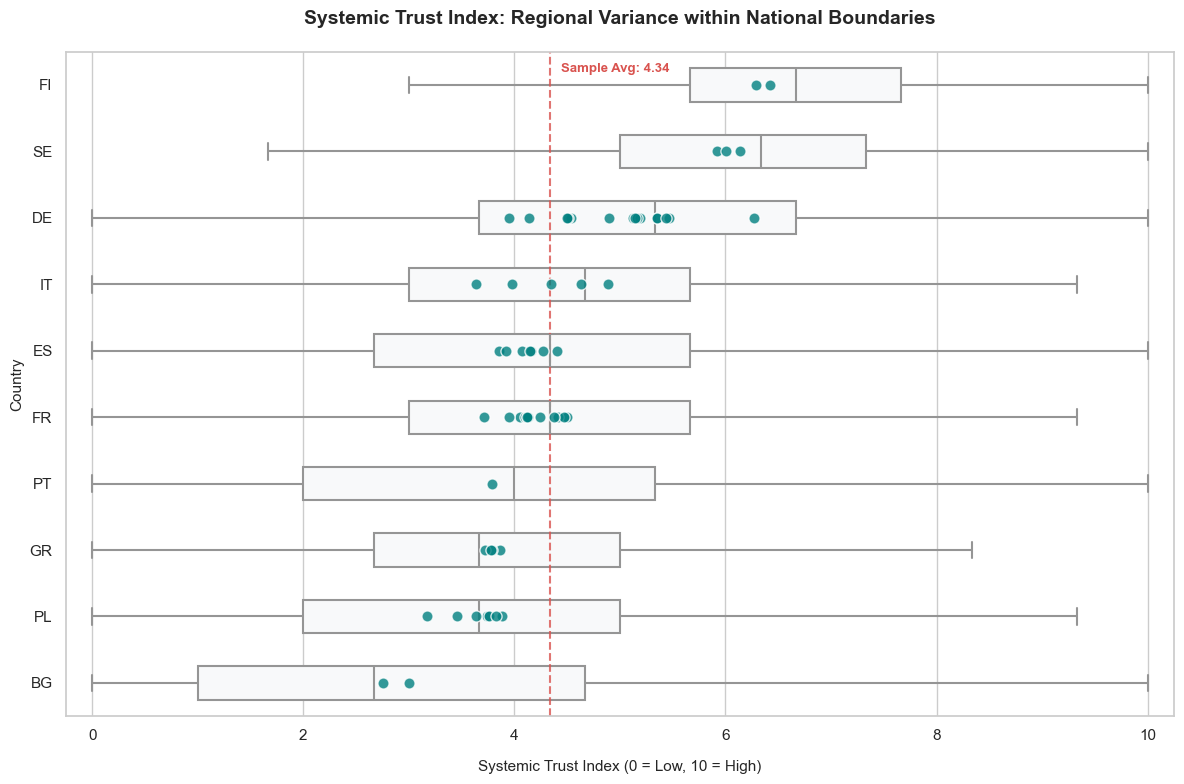

In [119]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Pre-calculate country medians to sort the categories beautifully
country_order = (
    ess_survey.groupby("country_code")["trust_index"]
    .median()
    .sort_values(ascending=False)
    .index
)

# 2. Draw a clean, minimalist horizontal boxplot for the national baseline
sns.boxplot(
    data=ess_survey,
    y="country_code",
    x="trust_index",
    order=country_order,
    color="#f8f9fa",      # Subtle neutral background for the national spread
    width=0.5,
    linewidth=1.5,
    showfliers=False,     # Hide individual respondent outliers to keep focus on regions
)

# 3. Layer regional averages as distinct, punchy points on top
# This maps the variance between NUTS1 regions explicitly
region_means = (
    ess_survey.groupby(["country_code", "nuts1_region"])["trust_index"]
    .mean()
    .reset_index()
)

sns.stripplot(
    data=region_means,
    y="country_code",
    x="trust_index",
    order=country_order,
    size=8,
    color="teal",
    alpha=0.8,
    linewidth=1,
    edgecolor="white",
    jitter=False,         # Keeping them aligned linearly lets you spot the spread easily
)

# 4. Polish labels and boundaries
plt.title(
    "Systemic Trust Index: Regional Variance within National Boundaries",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Systemic Trust Index (0 = Low, 10 = High)", fontsize=11, labelpad=12)
plt.ylabel("Country", fontsize=11)
plt.xlim(-0.25, 10.25)

# Add an explicit overall panel mean line for diagnostic grounding
overall_mean = ess_survey["trust_index"].mean()
plt.axvline(
    overall_mean, color="#d9534f", linestyle="--", linewidth=1.5, alpha=0.8
)
plt.text(
    overall_mean + 0.1,
    -0.2,
    f"Sample Avg: {overall_mean:.2f}",
    color="#d9534f",
    weight="bold",
    fontsize=9.5,
)

plt.tight_layout()

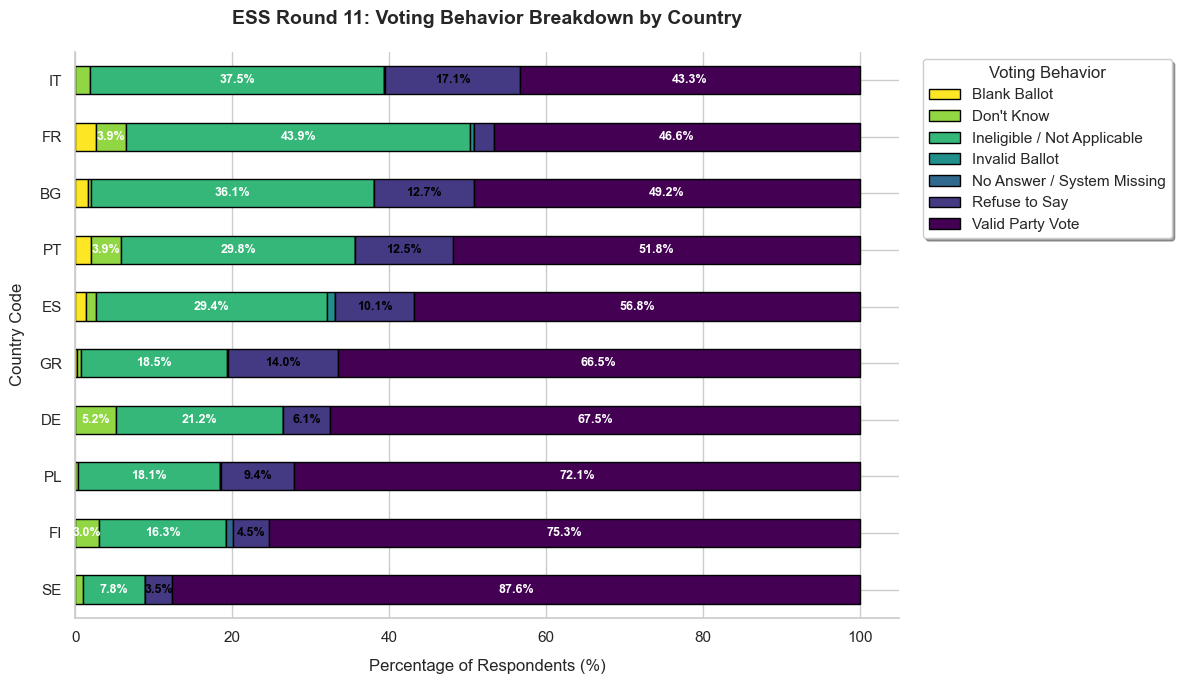

In [190]:
# 1. Calculate percentages of voting behavior by country
# This normalizes the row counts so we can see relative proportions
cross_tab = pd.crosstab(
    ess_survey["country_code"],
    ess_survey["voting_behavior_manifest"],
    normalize="index",  # Calculates percentages per row (country)
) * 100

# 2. Sort the countries by a specific category to make the visual cleaner
# Sorting by 'Valid Party Vote' gives the chart a nice visual gradient
cross_tab = cross_tab.sort_values(by="Valid Party Vote", ascending=False)

# 3. Plotting the 100% Stacked Bar Chart
ax = cross_tab.plot(
    kind="barh", stacked=True, figsize=(12, 7), cmap="viridis_r", edgecolor="black"
)

# 4. Styling and Aesthetics
sns.despine()  # Cleans up the top and right borders
plt.title(
    "ESS Round 11: Voting Behavior Breakdown by Country",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Percentage of Respondents (%)", fontsize=12, labelpad=10)
plt.ylabel("Country Code", fontsize=12, labelpad=10)

# Move the legend outside so it doesn't overlap the bars
plt.legend(
    title="Voting Behavior",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    shadow=True,
)

# 5. Add percentage labels directly onto the bars for scannability
# (Only adds labels for blocks larger than 3% to avoid messy overlap)
for p in ax.patches:
    width = p.get_width()
    if width > 3:  # Skip labeling tiny slices (like system slips)
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(
            x,
            y,
            f"{width:.1f}%",
            ha="center",
            va="center",
            color="white" if p.get_facecolor()[2] < 0.5 else "black",
            fontsize=9,
            weight="bold",
        )

plt.tight_layout()
plt.show()

## Regressions
To test for potential multicollinearity across our individual and macro-regional variables, Variance Inflation Factors (VIF) were calculated across all independent variables. All core individual-level attitudinal and socioeconomic controls display highly robust independence, with VIF scores resting well below 2.0. Mild elevation was observed in the country codes and macro delta variables. This covariance is a natural mathematical reflection of nested macroeconomic variations across Europe. Because all features (except for Greece country code) remain safely below the conservative threshold of 10.0, and our regression specifications utilize country-clustered standard errors, the model is mathematically stable and free from problematic multicollinearity.

In [194]:

# =====================================================================
# 1. PREPARE THE DESIGN MATRIX (X)
# =====================================================================
# Select ONLY the independent variables going into formula
vif_features = [
    "trust_index",
    "immigrants_impact_country",
    "left_right_alignment",
    "educ_attainment",
    "intergen_educational_mobility",
    "hh_income_comfort",
    "unemp_last_5_years",
    "age",
    "gender",
    "delta_nuts1_gdp_percap_pps_euro_5yr",
    "delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr",
    "country_code" # Categorical - must be encoded
]
# Drop missing rows across these specific features to align with model universe
df_vif_prep = ess_survey[vif_features].dropna().copy()

# Convert categorical country_code into 0/1 numeric dummy columns 
# (drop_first=True mirrors exactly how statsmodels treats C(country_code) references)
X = pd.get_dummies(df_vif_prep, columns=["country_code"], drop_first=True, dtype=int)

# CRITICAL STEP: statsmodels VIF requires an explicit intercept/constant column
X = sm.add_constant(X)

# =====================================================================
# 2. CALCULATE VARIANCE INFLATION FACTORS
# =====================================================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Filter out the constant row so we focus entirely on our variables
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

print("═" * 60)
print("VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS")
print("═" * 60)
print(vif_data.to_string(index=False, formatters={"VIF": "{:.2f}".format}))

════════════════════════════════════════════════════════════
VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS
════════════════════════════════════════════════════════════
                                  Feature   VIF
                          country_code_GR 10.98
        delta_nuts1_unemployment_rate_5yr  7.52
                          country_code_DE  7.45
delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr  6.74
                          country_code_ES  6.70
                          country_code_FR  5.55
                          country_code_IT  4.88
                          country_code_FI  4.53
                          country_code_SE  4.05
                          country_code_PL  2.93
                          country_code_PT  2.91
      delta_nuts1_gdp_percap_pps_euro_5yr  2.52
            delta_nuts1_net_migration_2yr  2.39
                          educ_attainment  1.94
            intergen_educational_mobility  1.75
                        hh_income_comfort  1.44
                  

### Macro level model

In [195]:
model_cols = [
    "radical_right_vote",
    "model_analysis_wt",

    "delta_nuts1_gdp_percap_pps_euro_5yr",
    "delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr",

    "trust_index",
    "immigrants_impact_country",
    "educ_attainment",
    "gender",
    "age",

    "country_code",
    "nuts1_region"
]

# Clean sample
df_models = ess_survey[model_cols].dropna().copy()
df_models_macro = df_models[~df_models['country_code'].isin(['PT', 'FI'])].copy() # need to exclude because only 1 NUTS 1 region, ie the country, no regional variation, multicollinear with fixed effects

# Standardise macro variables (single, consistent step)
macro_vars = [
    "delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr",
    "delta_nuts1_unemployment_rate_5yr",
    "delta_nuts1_net_migration_2yr"
]

scaler = StandardScaler()
df_models_macro[macro_vars] = scaler.fit_transform(df_models_macro[macro_vars])

# Model specification (fixed syntax)
macro_formula = (
    "radical_right_vote ~ "
    "delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr + "
    "delta_nuts1_unemployment_rate_5yr + "
    "delta_nuts1_net_migration_2yr + "
    "C(country_code)"
)

macro_logit_model = smf.glm(
    formula=macro_formula,
    data=df_models_macro,
    family=sm.families.Binomial(),
    var_weights=df_models_macro["model_analysis_wt"]
).fit()

print(macro_logit_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     radical_right_vote   No. Observations:                 9542
Model:                            GLM   Df Residuals:                     9531
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3085.5
Date:                Thu, 18 Jun 2026   Deviance:                       6170.9
Time:                        23:48:17   Pearson chi2:                 9.18e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07354
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

#### Interpretation
The macro-only specification challenges standard economic-shock narratives, revealing that individual anxieties are far more complex than simple regional downturns. After accounting for country fixed effects, 5-year changes in relative GDP growth are statistically insignificant. Intriguingly, both falling regional unemployment (P=0.034) and lower net migration growth (P=0.006) are significantly associated with increased radical-right voting. This suggests that the radical right thrives not in regions facing acute, immediate economic collapse, but potentially in stabilizing or monocultural regions experiencing cultural anxieties or a 'fear of falling.' Ultimately, the dominant coefficients remain the country fixed effects—particularly in France and Italy—proving that national political landscapes and institutional contexts explain far more variation than short-run regional macroeconomic shifts. The model is retained primarily as a transparency check demonstrating that regional macroeconomic indicators were tested but do not by themselves provide a strong standalone explanation of individual right wing voting behavior.

### Individual level model (with mobility)

In [ ]:
# Individual model version 1
# Isolate individual-level features 
model_cols = [
    "radical_right_vote",  # Target (Dropped NaNs natively restrict to active voters)
    "model_analysis_wt", # Weighting variable
    "trust_index",  # Replaced individual trst_pol_parties
    "immigrants_impact_country", 
    "intergen_educational_mobility",
    "educ_attainment",
    "hh_income_comfort",
    "unemp_last_5_years",
    "gender",
    "age",
    "country_code",  # Used for baseline country fixed-effects
]


# Create a clean modeling matrix free of missing values
df_logit = ess_survey[model_cols].dropna()

# ==========================================
# 2. FIT THE FIXED-EFFECTS LOGISTIC MODEL
# ==========================================

logit_model_mobility = smf.glm(
    formula="radical_right_vote ~ trust_index + immigrants_impact_country + educ_attainment + intergen_educational_mobility + hh_income_comfort + unemp_last_5_years + gender + age + C(country_code)",
    data=df_logit,
    family=sm.families.Binomial(),
    freq_weights=df_logit["model_analysis_wt"] # <-- CRITICAL ADDITION
).fit()
# Print the final baseline parameter diagnostics
print(logit_model_mobility.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:       rw_populist_vote   No. Observations:                 8319
Model:                            GLM   Df Residuals:                  7985.93
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2748.2
Date:                Tue, 16 Jun 2026   Deviance:                       5496.4
Time:                        02:57:17   Pearson chi2:                 8.38e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1903
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

 With a heavy heart, I am dropping the intergenerational mobility variable (intergenerational education deviation) from the main specification. Although it was designed to capture whether individuals are above or below the educational level of their parents, in practice it is highly correlated with education and does not materially improve model fit or change the main conclusions.

 When included, it produces a small but significant positive coefficient, but the implications are ambiguous. Given that the goal of the project is to explain voting behaviour in a way that is interpretable and accessible, especially for a non-technical audience, the added complexity of this variable outweighs its marginal explanatory benefit.

 For this reason, the main model focuses on absolute education (educ_attainment) as the more straightforward and interpretable measure of socioeconomic position, while mobility is included above for robustness checks and exploratory analysis.

In [82]:
ess_survey["intergen_educational_mobility"].isna().sum() # 679, this is meaningful and likely non-random
ess_survey["educ_attainment"].isna().sum() # 78

# Verifying relationship between educational attainment and intergenerational mobility, danger of multicollinearity
df_logit["intergen_educational_mobility"].describe()

df_logit[["educ_attainment",
          "intergen_educational_mobility"]].corr()

,educ_attainment,intergen_educational_mobility
educ_attainment,1.000000,0.458428
intergen_educational_mobility,0.458428,1.000000


### No mobility

In [196]:
# Intercept is DE
# Gender: 0 is male, 1 is female
logit_model_individual = smf.glm(
    formula="""
        radical_right_vote ~
        trust_index +
        immigrants_impact_country +
        educ_attainment +
        gender +
        age +
      C(country_code)
    """,
    data=df_models,
    family=sm.families.Binomial(),
    var_weights=df_models["model_analysis_wt"]
).fit()

print(logit_model_individual.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     radical_right_vote   No. Observations:                11399
Model:                            GLM   Df Residuals:                    11384
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3270.6
Date:                Thu, 18 Jun 2026   Deviance:                       6541.1
Time:                        23:48:21   Pearson chi2:                 1.21e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1445
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

**Individual-Level Predictors of Right-Wing Voting: Model Results**

The results indicate that individual-level attitudes are strongly associated with radical-right voting, with negative perceptions of immigration and lower institutional trust showing the strongest relationships. Educational attainment is also negatively associated with support, although the effect is smaller than the attitudinal variables. Age and gender remain statistically significant but comparatively modest predictors, with lower support among older respondents and women.

Country fixed effects remain large and highly significant for several countries, particularly Italy, Finland, France, Sweden, and Spain, indicating substantial differences in baseline levels of radical-right voting across national contexts even after accounting for individual characteristics. A few countries, such as Germany, Greece, Poland, and Portugal, do not differ significantly from the reference category (Bulgaria) in this specification.

Overall, the model suggests that radical-right voting is primarily structured by individual attitudes, especially toward immigration and political trust, while also reflecting strong and persistent differences between national political environments.


### Combined model

In [197]:
# Intercept is DE
# Gender: 0 is male, 1 is female
combined_model = smf.glm(
    formula="""
        radical_right_vote ~
        trust_index +
        immigrants_impact_country +
        educ_attainment +
        gender +
        age +
        C(country_code) +
        delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr +
        delta_nuts1_unemployment_rate_5yr +
        delta_nuts1_net_migration_2yr
    """,
    data=df_models_macro,
    family=sm.families.Binomial(),
    var_weights=df_models_macro["model_analysis_wt"]
).fit()

print(combined_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     radical_right_vote   No. Observations:                 9542
Model:                            GLM   Df Residuals:                     9526
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2708.3
Date:                Thu, 18 Jun 2026   Deviance:                       5416.6
Time:                        23:48:24   Pearson chi2:                 1.01e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1440
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

The combined model brings together individual attitudes, demographic characteristics, regional economic indicators, and country fixed effects to assess their joint association with radical right voting. The results indicate that individual-level attitudinal variables, particularly perceptions of immigration and institutional trust, are the strongest and most consistent predictors. Educational attainment is also negatively associated with radical right voting, while age and gender show smaller but statistically reliable effects.
Regional economic variables add only limited additional information. Changes in unemployment and migration are associated with radical right voting, whereas GDP growth and other contextual measures show no robust relationship. These effects are modest compared to individual attitudes.
Even after accounting for both individual and regional factors, substantial differences remain between countries, suggesting persistent national-level structuring of political behaviour.
Overall, the results indicate that radical right voting is primarily associated with individual attitudes, with weaker and more selective contributions from regional conditions, alongside strong and persistent national differences.

## K-Means Clustering of Region Types

Although silhouette scores peak at higher k values, k=6 balances structural separation with interpretability and cross-scaling stability. The clustering should be interpeted as a discretization of a continuous spectrum rather than sharply separated regime types.

In [200]:
# ============================================================
# 1. CLEAN REGION-LEVEL DATA (LOSSLESS BEFORE FEATURE FILTERING)
# ============================================================

df_clean = ess_survey.dropna(subset=["model_analysis_wt", "nuts1_region"]).copy()

regional_data = []

for name, g in df_clean.groupby("nuts1_region"):

    if len(g) < 50:
        continue

    regional_data.append({
        "nuts1_region": name,
        "country_code": g["country_code"].iloc[0],
        "sample_size": len(g),

        # macro variables (region-level constants)
        "gdp": g["nuts1_gdp_percap_pps_pct_eu_avg_2022"].iloc[0],
        "unemployment": g["nuts1_unemployment_rate_pct_2022"].iloc[0],
        "migration": g["nuts1_net_migration_2022"].iloc[0],
    })

df_regions = pd.DataFrame(regional_data)

cluster_features = ["gdp", "unemployment", "migration"]

# IMPORTANT: only drop rows missing clustering inputs, not entire region table
df_regions = df_regions.dropna(subset=cluster_features)


# ============================================================
# 2. STANDARDISE FEATURES
# ============================================================

X = RobustScaler().fit_transform(df_regions[cluster_features])


# ============================================================
# 3. K-SELECTION (STABLE)
# ============================================================

def evaluate_k_range(X, k_min=2, k_max=8):
    results = []

    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=50)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)

        results.append((k, score))

    return pd.DataFrame(results, columns=["k", "silhouette"]).sort_values("k")


k_results = evaluate_k_range(X, 3, 10)
print(k_results)


# ============================================================
# 4. FINAL KMEANS
# ============================================================

k_opt = 6 # we choose this for interpretability and to not overpartition beyond what is comprehensible

km = KMeans(n_clusters=k_opt, random_state=42, n_init=50)
df_regions[f"cluster_k{k_opt}"] = km.fit_predict(X)


# ============================================================
# 5. MERGE TO INDIVIDUAL DATA (STRICT VALIDATION)
# ============================================================

df_with_clusters = df_clean.merge(
    df_regions[["nuts1_region", f"cluster_k{k_opt}"]],
    on="nuts1_region",
    how="left",
    validate="m:1"
)

# enforce completeness for behavioural analysis
df_with_clusters = df_with_clusters.dropna(subset=[f"cluster_k{k_opt}"])


# ============================================================
# 6. STRUCTURAL PROFILES (REGION LEVEL)
# ============================================================

features = ["gdp", "unemployment", "migration"]

def build_structural_profile(df, cluster_col):
    profile = df.groupby(cluster_col)[features].mean()
    profile_z = (profile - profile.mean()) / profile.std()
    return profile, profile_z


# ============================================================
# 7. BEHAVIOURAL PROFILES (INDIVIDUAL WEIGHTED AGGREGATION)
# ============================================================

overlay_vars = [
    "radical_right_vote",
    "trust_index",
    "educ_attainment",
    "immigrants_impact_country"
]


def weighted_mean(group, col):
    x = group[col].to_numpy()
    w = group["model_analysis_wt"].to_numpy()

    mask = ~np.isnan(x) & ~np.isnan(w)

    if mask.sum() == 0:
        return np.nan

    return np.average(x[mask], weights=w[mask])


def build_behavioural_profile(df, cluster_col):
    records = []

    for cluster_id, group in df.groupby(cluster_col):
        row = {"cluster": cluster_id}

        for var in overlay_vars:
            row[var] = weighted_mean(group, var)

        records.append(row)

    profile = pd.DataFrame(records).set_index("cluster")
    profile_z = (profile - profile.mean()) / profile.std()

    return profile, profile_z


# ============================================================
# 8. COMPUTE PROFILES
# ============================================================

struct_k, struct_k_z = build_structural_profile(df_regions, f"cluster_k{k_opt}")
behav_k, behav_k_z = build_behavioural_profile(df_with_clusters, f"cluster_k{k_opt}")


# ============================================================
# 9. OUTPUT
# ============================================================

print(f"\n=== K={k_opt} STRUCTURAL ===\n")
print(struct_k_z.round(2))

print(f"\n=== K={k_opt} BEHAVIOURAL ===\n")
print(behav_k_z.round(2))

print("\nCluster sizes:")
print(df_regions[f"cluster_k{k_opt}"].value_counts().sort_index())

    k  silhouette
0   3    0.303194
1   4    0.328595
2   5    0.366500
3   6    0.384906
4   7    0.405686
5   8    0.390973
6   9    0.394568
7  10    0.378646

=== K=6 STRUCTURAL ===

             gdp  unemployment  migration
cluster_k6                               
0          -1.23          1.30      -0.42
1           0.72         -0.63       0.09
2          -0.32          1.28       1.38
3          -0.18         -0.58       0.81
4          -0.57         -0.60      -0.41
5           1.58         -0.76      -1.44

=== K=6 BEHAVIOURAL ===

         radical_right_vote  trust_index  educ_attainment  \
cluster                                                     
0.0                    0.21        -0.60            -1.10   
1.0                    1.83         1.53             0.92   
2.0                   -0.88        -0.26            -0.55   
3.0                   -0.19        -0.35            -1.00   
4.0                   -0.09        -1.17             1.10   
5.0                   -0

In [201]:
cluster_labels = {
    0: "Economically Deprived Periphery",
    1: "Established Radical Right Influence",
    2: "High Migration Low Backlash Regions",
    3: "Vulnerable Battlegrounds",
    4: "Alienated and Educated Skeptics",
    5: "Status Quo Powerhouses"
}

cluster_colors = {
    0: "#4C78A8",  # Muted Blue (Deprived periphery economic strain)
    1: "#F58518",  # Vivid Orange (Mainstreamed, high-trust far-right core)
    2: "#54A24B",  # Green (Migration/unemployment heavy progressive gateway)
    3: "#E45756",  # Red (Culturally traditional industrial battlegrounds)
    4: "#B279A2",  # Purple (Deeply alienated, highly educated skeptics)
    5: "#76B7B2"   # Teal/Cyan (Hyper-affluent, insulated economic engines)
}

# =========================================================
# 2. CLUSTER DATA PREP
# =========================================================

cluster_col = f"cluster_k{k_opt}"

cluster_map = df_regions[["nuts1_region", cluster_col]].copy()
cluster_map[cluster_col] = cluster_map[cluster_col].astype(int)

df_plot = df_clean.merge(
    cluster_map,
    on="nuts1_region",
    how="left"
)

# =========================================================
# 3. RIGHTWING VOTE INTENSITY AT REGION LEVEL
# =========================================================

pop_map = (
    df_plot.groupby("nuts1_region")["radical_right_vote"]
    .mean()
    .reset_index()
)

# =========================================================
# 4. SUBPLOTS
# =========================================================

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=(
        f"Structural Regional Typology (k={k_opt})",
        "Radical Right Vote Intensity"
    )
)

# =========================================================
# 5. LEFT: STRUCTURAL CLUSTERS
# =========================================================

for cid in sorted(cluster_map[cluster_col].dropna().unique()):
    sub = cluster_map[cluster_map[cluster_col] == cid]

    fig.add_trace(
        go.Choropleth(
            geojson=nuts1_geojson,
            locations=sub["nuts1_region"],
            featureidkey="properties.NUTS_ID",
            z=[cid] * len(sub),

            name=cluster_labels[cid],
            colorscale=[[0, cluster_colors[cid]], [1, cluster_colors[cid]]],

            showscale=False,
            showlegend=True,
            marker_line_width=0.3,

            hovertemplate=(
                "<b>%{location}</b><br>"
                "Structural type: " + cluster_labels[cid] +
                "<extra></extra>"
            ),
        ),
        row=1,
        col=1
    )

# =========================================================
# 6. RIGHT: RADICAL RIGHT VOTE INTENSITY
# =========================================================

fig.add_trace(
    go.Choropleth(
        geojson=nuts1_geojson,
        locations=pop_map["nuts1_region"],
        featureidkey="properties.NUTS_ID",
        z=pop_map["radical_right_vote"],

        colorscale="Reds",
        zmin=0,
        zmax=pop_map["radical_right_vote"].max(),

        colorbar=dict(
            title="Radical Right Vote Share",
            x=1.02,
            xanchor="left",
            len=0.6,
            y=0.5
        ),

        hovertemplate=(
            "<b>%{location}</b><br>"
            "Radical right vote: %{z:.2%}"
            "<extra></extra>"
        ),
        showscale=True
    ),
    row=1,
    col=2
)

# =========================================================
# 7. LAYOUT
# =========================================================

geo_style = dict(
    scope="europe",
    showcountries=True,
    countrycolor="rgba(60, 60, 60, 0.35)",
    showsubunits=True,
    subunitcolor="rgba(60, 60, 60, 0.15)",
    subunitwidth=0.5,
    showland=True,
    landcolor="rgba(245, 245, 245, 1)",
    projection_type="transverse mercator",
    center={"lat": 52.0, "lon": 10.0}
)

fig.update_layout(
    title_text=(
        f"European NUTS1 Structural Typology and Radical Right Voting Intensity "
        f"(k={k_opt} specification)"
    ),

    geo=geo_style,
    geo2=geo_style,

    legend=dict(
        title="Structural Segments",
        x=0.45,
        y=0.5,
        xanchor="center",
        yanchor="middle",
        font=dict(size=10)
    ),

    margin={"r": 120, "t": 100, "l": 20, "b": 20},
    height=650,
    width=1400
)

fig.show()

What Does the Data Actually Tell Us?

The headline finding cuts against the dominant narrative: economic stress alone does not predict where populism rises. The regions under the most structural pressure — high unemployment, rapid migration inflows, low GDP — are not the most politically reactive. Spain's regions absorb the highest migration acceleration in the dataset and return the lowest radical right vote share of any cluster. Southern Italy and Greece, the most economically deprived environments in the analysis, produce only average populist voting. If poverty and demographic change were the primary drivers, the map would look completely different.
Two contradictions stand out and resist easy resolution. First, the highest radical right vote share belongs to the most affluent, highest-trust, best-educated cluster — Sweden, Finland, and northern Italy — which breaks the assumption that prosperity and institutional quality act as reliable buffers. Populism in wealthy democracies appears to operate through identity and cultural politics rather than economic grievance, and our individual-level model, which finds immigration attitudes as the single strongest predictor of populist voting, is consistent with this. Second, the cluster with the lowest institutional trust — covering much of France, Poland, and Bulgaria — does not produce the highest populist vote share, suggesting that distrust is a necessary but not sufficient condition: something in the national political landscape has to be present to convert alienation into votes.

In [202]:
# =====================================================================
# CONFIG
# =====================================================================

cluster_col = f"cluster_k{k_opt}"

# standardise region keys once (critical for stable joins)
ess_survey["nuts1_region"] = ess_survey["nuts1_region"].astype(str).str.strip().str.upper()
df_regions["nuts1_region"] = df_regions["nuts1_region"].astype(str).str.strip().str.upper()
df_with_clusters["nuts1_region"] = df_with_clusters["nuts1_region"].astype(str).str.strip().str.upper()


# =====================================================================
# ASSET 1: REGIONAL DATA (1 row per NUTS1 region)
# =====================================================================

# macro deltas (region-level signals)
regional_macro = ess_survey.groupby("nuts1_region").agg({
   "delta_nuts1_gdp_percap_pps_euro_5yr": "mean",
   "delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr": "mean",
    "delta_nuts1_net_migration_2yr": "mean",
    "nuts1_unemployment_rate_pct_2022": "mean"
}).reset_index()

# base structural + cluster data
df_regional_dashboard = df_regions[
    ["nuts1_region", "country_code", "sample_size",
     "gdp", "unemployment", "migration", cluster_col]
].copy()

# merge macro signals
df_regional_dashboard = df_regional_dashboard.merge(
    regional_macro,
    on="nuts1_region",
    how="left",
    validate="1:1"
)

# enforce cluster completeness (critical for Streamlit filters)
df_regional_dashboard = df_regional_dashboard.dropna(subset=[cluster_col])

# export
df_regional_dashboard.to_csv(
    "streamlit/dashboard_regional_data.csv",
    index=False
)


# =====================================================================
# ASSET 2: INDIVIDUAL DATA (1 row per respondent)
# =====================================================================

model_vars = [
    "nuts1_region",
    "country_code",
    "trust_index",
    "voting_behavior_manifest",
    "radical_right_vote",
    "immigrants_impact_country",
    "educ_attainment",
    "gender",
    "age",
    "delta_nuts1_gdp_percap_pps_pct_eu_avg_5yr" ,
    "delta_nuts1_unemployment_rate_5yr" ,
    "delta_nuts1_net_migration_2yr"
]

df_model_dashboard = df_with_clusters[model_vars].copy()

# attach cluster via safe merge (NOT dict mapping — avoids silent mismatch)
df_model_dashboard = df_model_dashboard.merge(
    df_regions[["nuts1_region", cluster_col]],
    on="nuts1_region",
    how="left",
    validate="m:1"
)

# remove unresolved assignments (important for downstream filtering)
df_model_dashboard = df_model_dashboard.dropna(subset=[cluster_col])

# export
df_model_dashboard.to_csv(
    "streamlit/dashboard_individual_data.csv",
    index=False
)

# =====================================================================
# ASSET 3: MODEL SUMMARY EXPORT
# =====================================================================

# html_summary = combined_model.summary().as_html()

# with open("streamlit/combined_model_summary.html", "w") as f:
#     f.write(html_summary)
# =====================================================================
# ASSET 3: MODEL SUMMARY EXPORT
# =====================================================================

# Extracting stats directly guarantees a clean table matching your app's schema
df_summary = pd.DataFrame({
    "variable": logit_model_individual.params.index,
    "coef": logit_model_individual.params.values,
    "stderr": logit_model_individual.bse.values,
    "pvalue": logit_model_individual.pvalues.values
})

# Export directly as the clean CSV asset required by the dashboard
df_summary.to_csv("streamlit/regression_summary_1.csv", index=False)